In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import pathlib

sns.set_style("whitegrid")
sns.set_context("paper")
sns.set_palette("deep", color_codes=True)

In [2]:
df = pd.read_pickle("phase2_results.pkl")
df

,seed,bitstring,biological_energy,energy_diff,protein,residues,residue_count,rotamers,num_qubits,classification
0,0,"(1, 0, 1, 0, 1, 0, 0, 0, 0)",153.162634,0.239138,AF-5PTI,56_59,4,5,9,tie
1,1,"(1, 0, 1, 0, 1, 0, 0, 0, 0)",153.162634,0.239138,AF-5PTI,56_59,4,5,9,tie
2,2,"(1, 0, 1, 0, 1, 0, 0, 0, 0)",153.162634,0.239138,AF-5PTI,56_59,4,5,9,tie
3,3,"(1, 0, 1, 0, 1, 0, 0, 0, 0)",153.162634,0.239138,AF-5PTI,56_59,4,5,9,tie
4,4,"(1, 0, 1, 0, 1, 0, 0, 0, 0)",153.162634,0.239138,AF-5PTI,56_59,4,5,9,tie
...,...,...,...,...,...,...,...,...,...,...
865,25,"(1, 0, 1, 0, 1, 0, 0)",153.162634,0.239138,AF-5PTI,56_59,4,3,7,tie
866,26,"(1, 0, 1, 0, 1, 0, 0)",153.162634,0.239138,AF-5PTI,56_59,4,3,7,tie
867,27,"(1, 0, 1, 0, 1, 0, 0)",153.162634,0.239138,AF-5PTI,56_59,4,3,7,tie
868,28,"(1, 0, 1, 0, 1, 0, 0)",153.162634,0.239138,AF-5PTI,56_59,4,3,7,tie


In [4]:
filtered_df = df[df["energy_diff"] == df.energy_diff.min()]
filtered_df

,seed,bitstring,biological_energy,energy_diff,protein,residues,residue_count,rotamers,num_qubits,classification
180,0,"(1, 0, 0, 0, 0)",150.628504,-2.294992,AF-5PTI,60_63,4,5,5,win
181,1,"(1, 0, 0, 0, 0)",150.628504,-2.294992,AF-5PTI,60_63,4,5,5,win
182,2,"(1, 0, 0, 0, 0)",150.628504,-2.294992,AF-5PTI,60_63,4,5,5,win
183,3,"(1, 0, 0, 0, 0)",150.628504,-2.294992,AF-5PTI,60_63,4,5,5,win
184,4,"(1, 0, 0, 0, 0)",150.628504,-2.294992,AF-5PTI,60_63,4,5,5,win
185,5,"(1, 0, 0, 0, 0)",150.628504,-2.294992,AF-5PTI,60_63,4,5,5,win
186,6,"(1, 0, 0, 0, 0)",150.628504,-2.294992,AF-5PTI,60_63,4,5,5,win
187,7,"(1, 0, 0, 0, 0)",150.628504,-2.294992,AF-5PTI,60_63,4,5,5,win
188,8,"(1, 0, 0, 0, 0)",150.628504,-2.294992,AF-5PTI,60_63,4,5,5,win
189,9,"(1, 0, 0, 0, 0)",150.628504,-2.294992,AF-5PTI,60_63,4,5,5,win


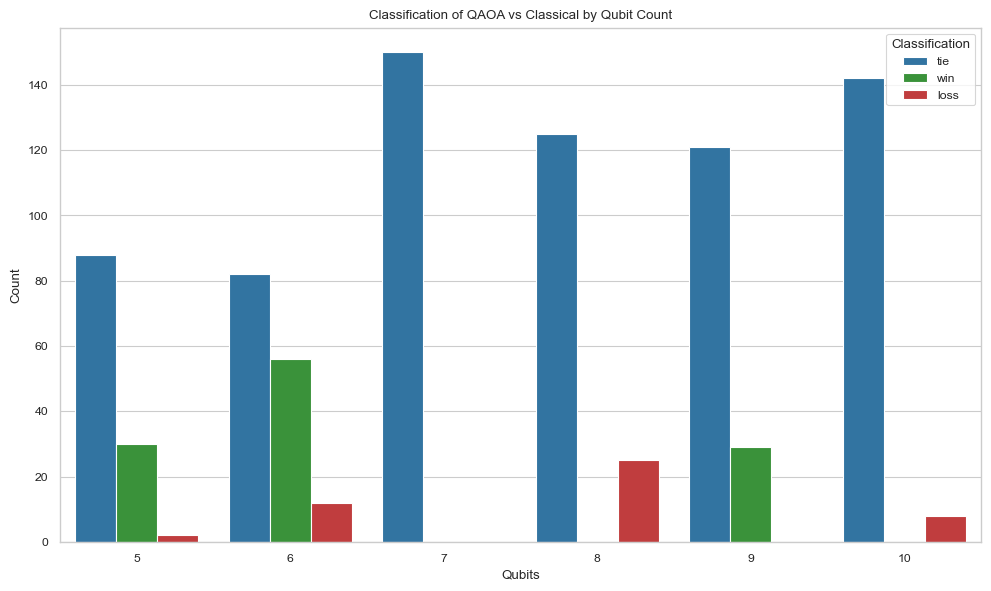

In [3]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="num_qubits", hue="classification", palette={"win": "#2ca02c", "loss": "#d62728", "tie": "#1f77b4"})
plt.xlabel("Qubits")
plt.ylabel("Count")
plt.title("Classification of QAOA vs Classical by Qubit Count")
plt.legend(title="Classification")
plt.tight_layout()
plt.savefig("../plots/classification_counts_5_10_qubits.svg", dpi=300, bbox_inches="tight")
plt.show()

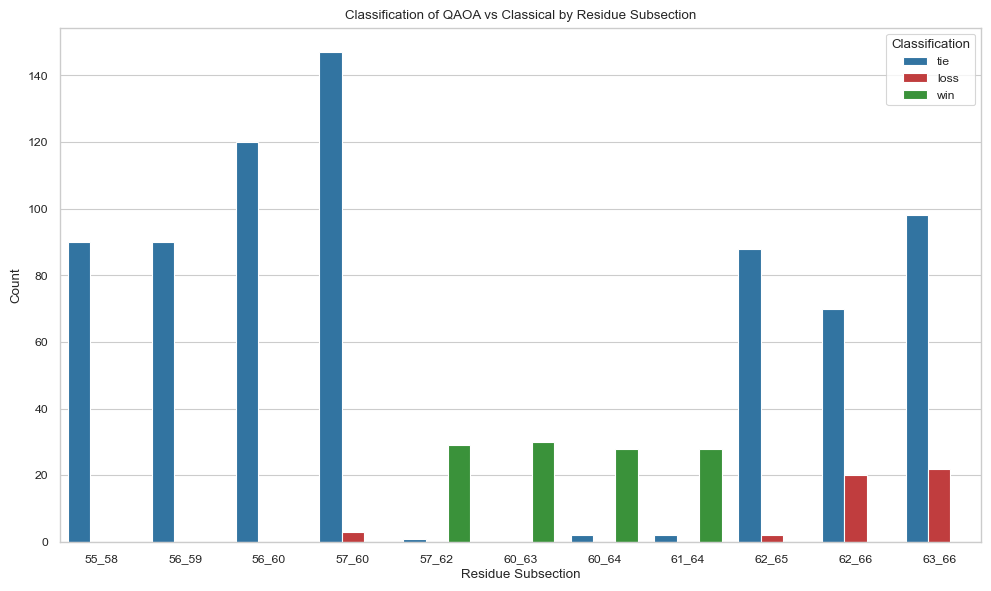

In [4]:
residue_order = (
    df["residues"]
    .dropna()
    .unique()
)

residue_order = sorted(
    residue_order,
    key=lambda s: tuple(map(int, s.split("_")))  # e.g. "18_24" -> (18, 24)
)

plt.figure(figsize=(10, 6))
sns.countplot(
    data=df,
    x="residues",
    hue="classification",
    order=residue_order,
    palette={"win": "#2ca02c", "loss": "#d62728", "tie": "#1f77b4"},
)
plt.xlabel("Residue Subsection")
plt.ylabel("Count")
plt.title("Classification of QAOA vs Classical by Residue Subsection")
plt.legend(title="Classification")
plt.tight_layout()

plt.savefig("../plots/classification_counts_5_10_qubits_by_subsection.svg", dpi=300, bbox_inches="tight")

plt.show()

In [5]:
df.classification.value_counts()

classification
tie     708
win     115
loss     47
Name: count, dtype: int64

In [15]:
df.groupby("residues").energy_diff.agg(min)

residues
55_58    0.664836
56_59    0.239138
56_60    0.270652
57_60   -0.405888
57_62   -1.915339
60_63   -2.294992
60_64   -1.530874
61_64   -1.550627
62_65    0.744458
62_66    1.371490
63_66    1.349353
Name: energy_diff, dtype: float64

In [5]:
df2 = pd.read_pickle("phase2_11_to_14_results.pkl")
df2


,seed,bitstring,biological_energy,energy_diff,protein,residues,residue_count,rotamers,num_qubits,classification
0,0,"(1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0)",153.623818,0.700322,AF-5PTI,64_67,4,5,14,tie
1,1,"(1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0)",153.623818,0.700322,AF-5PTI,64_67,4,5,14,tie
2,2,"(1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0)",153.623818,0.700322,AF-5PTI,64_67,4,5,14,tie
3,3,"(1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0)",153.623818,0.700322,AF-5PTI,64_67,4,5,14,tie
4,4,"(1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0)",153.623818,0.700322,AF-5PTI,64_67,4,5,14,tie
...,...,...,...,...,...,...,...,...,...,...
595,25,"(1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0)",151.008157,-1.915339,AF-5PTI,57_62,6,5,13,win
596,26,"(1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0)",151.008157,-1.915339,AF-5PTI,57_62,6,5,13,win
597,27,"(1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0)",151.008157,-1.915339,AF-5PTI,57_62,6,5,13,win
598,28,"(1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0)",151.008157,-1.915339,AF-5PTI,57_62,6,5,13,win


In [17]:
df2.groupby("residues").energy_diff.agg(min)

residues
52_55   -1.001821
52_57   -0.759543
53_56    0.484693
53_57    0.000979
56_61   -1.834044
56_62   -1.238799
57_62   -1.915339
57_64   -0.706047
61_68   -0.426020
62_66    1.371490
63_66    1.349353
64_67    0.700322
Name: energy_diff, dtype: float64

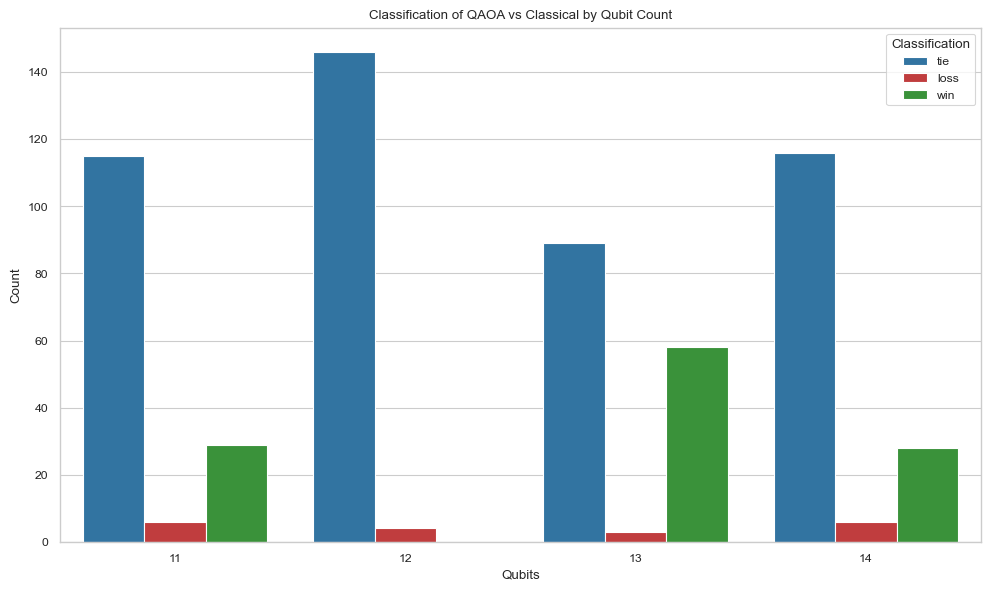

In [25]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df2, x="num_qubits", hue="classification", palette={"win": "#2ca02c", "loss": "#d62728", "tie": "#1f77b4"})
plt.xlabel("Qubits")
plt.ylabel("Count")
plt.title("Classification of QAOA vs Classical by Qubit Count")
plt.legend(title="Classification")
plt.tight_layout()
plt.savefig("../plots/classification_counts2.svg", dpi=300, bbox_inches="tight")
plt.show()

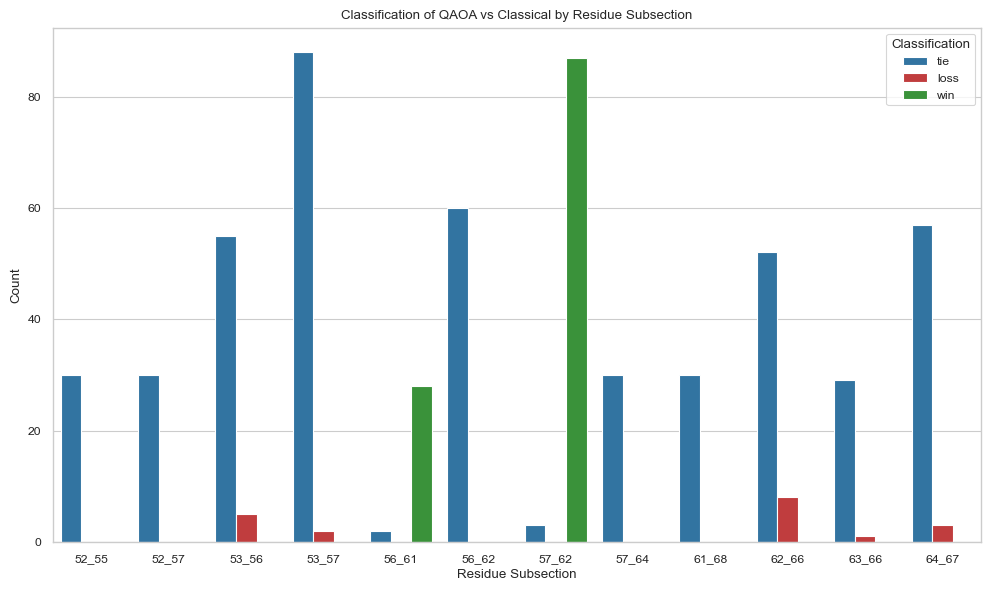

In [26]:
residue_order = (
    df2["residues"]
    .dropna()
    .unique()
)

residue_order = sorted(
    residue_order,
    key=lambda s: tuple(map(int, s.split("_")))  # e.g. "18_24" -> (18, 24)
)

plt.figure(figsize=(10, 6))
sns.countplot(
    data=df2,
    x="residues",
    hue="classification",
    order=residue_order,
    palette={"win": "#2ca02c", "loss": "#d62728", "tie": "#1f77b4"},
)
plt.xlabel("Residue Subsection")
plt.ylabel("Count")
plt.title("Classification of QAOA vs Classical by Residue Subsection")
plt.legend(title="Classification")
plt.tight_layout()
plt.show()

In [6]:
combined_df = pd.concat([df, df2], ignore_index=True)

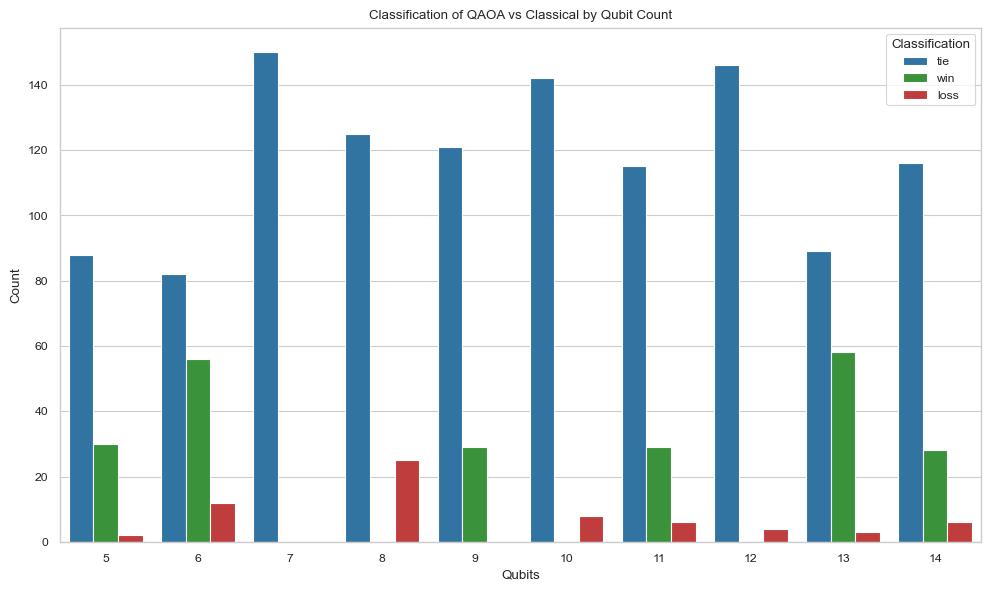

In [28]:
plt.figure(figsize=(10, 6))
sns.countplot(data=combined_df, x="num_qubits", hue="classification", palette={"win": "#2ca02c", "loss": "#d62728", "tie": "#1f77b4"})
plt.xlabel("Qubits")
plt.ylabel("Count")
plt.title("Classification of QAOA vs Classical by Qubit Count")
plt.legend(title="Classification")
plt.tight_layout()
plt.savefig("../plots/classification_counts3.svg", dpi=300, bbox_inches="tight")
plt.show()

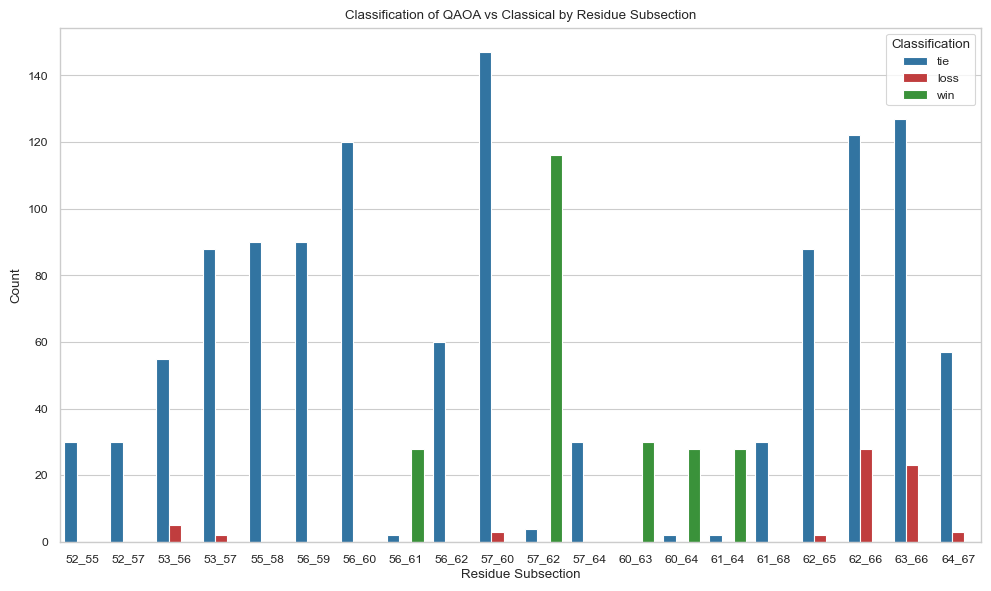

In [29]:
residue_order = (
    combined_df["residues"]
    .dropna()
    .unique()
)

residue_order = sorted(
    residue_order,
    key=lambda s: tuple(map(int, s.split("_")))  # e.g. "18_24" -> (18, 24)
)

plt.figure(figsize=(10, 6))
sns.countplot(
    data=combined_df,
    x="residues",
    hue="classification",
    order=residue_order,
    palette={"win": "#2ca02c", "loss": "#d62728", "tie": "#1f77b4"},
)
plt.xlabel("Residue Subsection")
plt.ylabel("Count")
plt.title("Classification of QAOA vs Classical by Residue Subsection")
plt.legend(title="Classification")
plt.tight_layout()
plt.show()

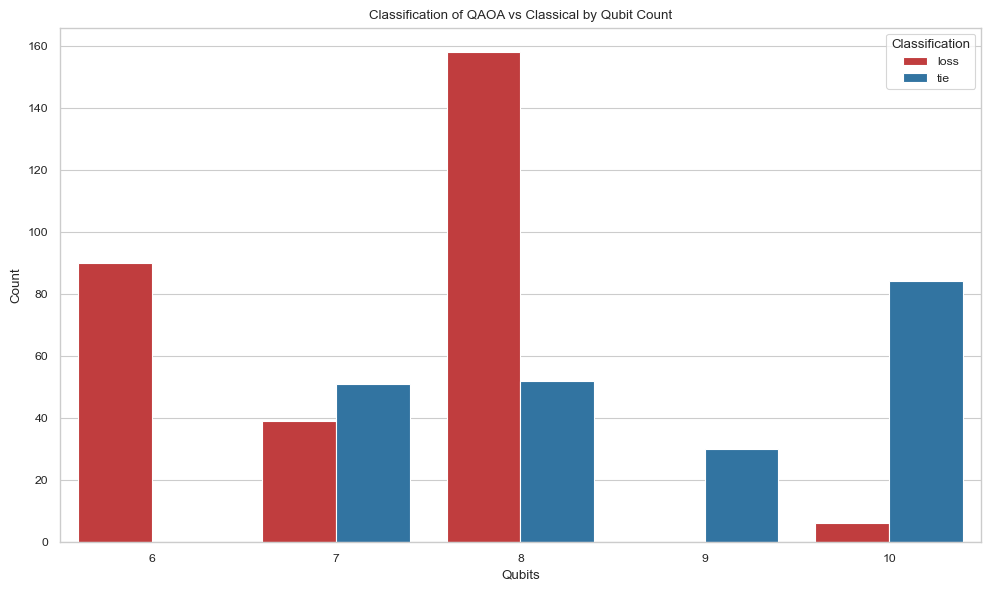

In [34]:
df = pd.read_pickle("phase2_old_runs.pkl")

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="num_qubits", hue="classification",
              palette={"win": "#2ca02c", "loss": "#d62728", "tie": "#1f77b4"})
plt.xlabel("Qubits")
plt.ylabel("Count")
plt.title("Classification of QAOA vs Classical by Qubit Count")
plt.legend(title="Classification")
plt.tight_layout()
plt.savefig("../plots/old_classifications.svg", dpi=300, bbox_inches="tight")
plt.show()

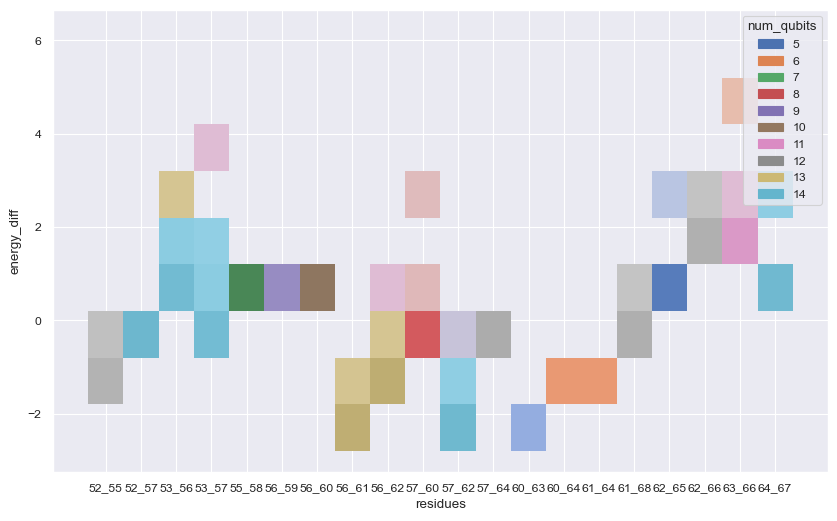

In [43]:
residue_order = (
    combined_df["residues"]
    .dropna()
    .unique()
)

residue_order = sorted(
    residue_order,
    key=lambda s: tuple(map(int, s.split("_")))  # e.g. "18_24" -> (18, 24)
)

combined_df['residues'] = pd.Categorical(combined_df['residues'], residue_order)
combined_df['classification'] = pd.Categorical(combined_df['classification'], ['win', 'tie', 'loss'])

plt.figure(figsize=(10, 6))
sns.histplot(
    combined_df,
    x="residues", y="energy_diff",
    hue="num_qubits",
    palette=sns.color_palette('deep'),
    discrete=True,
    shrink=0.8,
)

plt.show()

In [38]:
combined_df['abs_energy_diff'] = abs(combined_df['energy_diff'])

In [47]:
combined_df[['num_qubits', 'abs_energy_diff', 'energy_diff']].corr()

,num_qubits,abs_energy_diff,energy_diff
num_qubits,1.000000,-0.041064,-0.147544
abs_energy_diff,-0.041064,1.000000,-0.012083
energy_diff,-0.147544,-0.012083,1.000000


In [48]:
combined_df[['residues', 'abs_energy_diff', 'energy_diff']].corr()

,residues,abs_energy_diff,energy_diff
residues,1.0000,0.441800,0.408500
abs_energy_diff,0.4418,1.000000,-0.012083
energy_diff,0.4085,-0.012083,1.000000


In [52]:
combined_df['rot_res'] = combined_df['rotamers'] ** combined_df['residue_count']
combined_df[['num_qubits', 'residue_count', 'rotamers', 'rot_res']].corr()

,num_qubits,residue_count,rotamers,rot_res
num_qubits,1.000000,0.485681,0.014504,0.417160
residue_count,0.485681,1.000000,-0.328008,0.416919
rotamers,0.014504,-0.328008,1.000000,0.330396
rot_res,0.417160,0.416919,0.330396,1.000000


In [65]:
combined_df.classification.dtype

CategoricalDtype(categories=['win', 'tie', 'loss'], ordered=False, categories_dtype=str)

In [81]:
one_hot = pd.get_dummies(combined_df['classification'])
qubit_groups = combined_df.drop('classification', axis=1).join(one_hot).groupby('num_qubits')
qubit_groups = qubit_groups.agg({'win': 'sum', 'tie': 'sum', 'loss': 'sum'})
qubit_groups['total'] = qubit_groups.win + qubit_groups.tie + qubit_groups.loss
qubit_groups.win = qubit_groups.win/qubit_groups['total'] * 100
qubit_groups.tie = qubit_groups.tie/qubit_groups['total'] * 100
qubit_groups.loss = qubit_groups.loss/qubit_groups['total'] * 100
qubit_groups.drop('total', axis=1).reset_index().corr()

,num_qubits,win,tie,loss
num_qubits,1.000000,-0.010804,0.059864,-0.149839
win,-0.010804,1.000000,-0.947286,-0.194666
tie,0.059864,-0.947286,1.000000,-0.129855
loss,-0.149839,-0.194666,-0.129855,1.000000


In [84]:
residue_count_groups = combined_df.drop('classification', axis=1).join(one_hot).groupby('residue_count')
residue_count_groups = residue_count_groups.agg({'win': 'sum', 'tie': 'sum', 'loss': 'sum'})
residue_count_groups['total'] = residue_count_groups.win + residue_count_groups.tie + residue_count_groups.loss
residue_count_groups.win = residue_count_groups.win / residue_count_groups['total'] * 100
residue_count_groups.tie = residue_count_groups.tie / residue_count_groups['total'] * 100
residue_count_groups.loss = residue_count_groups.loss / residue_count_groups['total'] * 100
residue_count_groups.drop('total', axis=1).reset_index().corr()



,residue_count,win,tie,loss
residue_count,1.000000,-0.101538,0.184139,-0.755483
win,-0.101538,1.000000,-0.994873,-0.294677
tie,0.184139,-0.994873,1.000000,0.196523
loss,-0.755483,-0.294677,0.196523,1.000000


In [94]:
combined_df["test_name"] = combined_df["residues"].astype(str) + "_" + combined_df["rotamers"].astype(str)

residue_qubit_groups = combined_df.drop('classification', axis=1).join(one_hot).groupby(['test_name', 'num_qubits'])
residue_qubit_groups = residue_qubit_groups.agg({'win': 'sum', 'tie': 'sum', 'loss': 'sum'})
residue_qubit_groups['total'] = residue_qubit_groups.win + residue_qubit_groups.tie + residue_qubit_groups.loss
residue_qubit_groups.win = residue_qubit_groups.win / residue_qubit_groups['total'] * 100
residue_qubit_groups.tie = residue_qubit_groups.tie / residue_qubit_groups['total'] * 100
residue_qubit_groups.loss = residue_qubit_groups.loss / residue_qubit_groups['total'] * 100
residue_qubit_groups.drop('total', axis=1).reset_index().corr()


,test_name,num_qubits,win,tie,loss
test_name,1.000000,-0.343845,0.008132,-0.124851,0.469215
num_qubits,-0.343845,1.000000,0.003990,0.019665,-0.095728
win,0.008132,0.003990,1.000000,-0.970396,-0.231587
tie,-0.124851,0.019665,-0.970396,1.000000,-0.010224
loss,0.469215,-0.095728,-0.231587,-0.010224,1.000000


In [95]:
residue_qubit_groups = combined_df.drop('classification', axis=1).join(one_hot).groupby(['residue_count', 'num_qubits'])
residue_qubit_groups = residue_qubit_groups.agg({'win': 'sum', 'tie': 'sum', 'loss': 'sum'})
residue_qubit_groups['total'] = residue_qubit_groups.win + residue_qubit_groups.tie + residue_qubit_groups.loss
residue_qubit_groups.win = residue_qubit_groups.win / residue_qubit_groups['total'] * 100
residue_qubit_groups.tie = residue_qubit_groups.tie / residue_qubit_groups['total'] * 100
residue_qubit_groups.loss = residue_qubit_groups.loss / residue_qubit_groups['total'] * 100
residue_qubit_groups.drop('total', axis=1).reset_index().corr()

,residue_count,num_qubits,win,tie,loss
residue_count,1.000000,0.350102,0.291671,-0.231521,-0.293506
num_qubits,0.350102,1.000000,-0.071867,0.126619,-0.220131
win,0.291671,-0.071867,1.000000,-0.973144,-0.252307
tie,-0.231521,0.126619,-0.973144,1.000000,0.022782
loss,-0.293506,-0.220131,-0.252307,0.022782,1.000000


In [ ]:
residue_qubit_groups = combined_df.drop('classification', axis=1).groupby(['test_name', 'num_qubits'])
residue_qubit_groups = residue_qubit_groups.agg({'win': 'sum', 'tie': 'sum', 'loss': 'sum'})
residue_qubit_groups['total'] = residue_qubit_groups.win + residue_qubit_groups.tie + residue_qubit_groups.loss
residue_qubit_groups.win = residue_qubit_groups.win / residue_qubit_groups['total'] * 100
residue_qubit_groups.tie = residue_qubit_groups.tie / residue_qubit_groups['total'] * 100
residue_qubit_groups.loss = residue_qubit_groups.loss / residue_qubit_groups['total'] * 100
residue_qubit_groups.drop('total', axis=1).reset_index().corr()

In [96]:
columns_to_analyze = ['residue_count', 'num_qubits', 'energy_diff']

# Calculate the Pearson correlation matrix using the raw data
pearson_matrix = combined_df[columns_to_analyze].corr(method='pearson')

print("Pearson Correlation Matrix:")
print(pearson_matrix)

Pearson Correlation Matrix:
               residue_count  num_qubits  energy_diff
residue_count       1.000000    0.485681    -0.424619
num_qubits          0.485681    1.000000    -0.147544
energy_diff        -0.424619   -0.147544     1.000000


In [97]:
# Calculate the Spearman rank correlation matrix
spearman_matrix = df[columns_to_analyze].corr(method='spearman')

print("\nSpearman Correlation Matrix:")
print(spearman_matrix)


Spearman Correlation Matrix:
               residue_count  num_qubits  energy_diff
residue_count       1.000000    0.435212     0.048278
num_qubits          0.435212    1.000000     0.093834
energy_diff         0.048278    0.093834     1.000000


In [12]:
filtered_df = combined_df[combined_df.classification == 'win']
filtered_df.energy_diff.describe()

count    230.000000
mean      -1.863758
std        0.226617
min       -2.294992
25%       -1.915339
50%       -1.915339
75%       -1.834044
max       -1.530874
Name: energy_diff, dtype: float64